# Evaluación de Resultados 

En este NoteBook se muestran técnicas para la evaluación de los resultados de una predicción con un algoritmo de Machine Learning.

### DataSet

### Descripción 
NSL-KDD is a data set suggested to solve some of the inherent problems of the KDD'99 data set which are mentioned in [1]. Although, this new version of the KDD data set still suffers from some of the problems discussed by McHugh [2] and may not be a perfect representative of existing real networks, because of the lack of public data sets for network-based IDSs, we believe it still can be applied as an effective benchmark data set to help researchers compare different intrusion detection methods. Furthermore, the number of records in the NSL-KDD train and test sets are reasonable. This advantage makes it affordable to run the experiments on the complete set without the need to randomly select a small portion. Consequently, evaluation results of different research work will be consistent and comparable.

### Ficheros de Datos

* <span style = "color:green">**KDDTrain+.ARFF** - The full NSL-KDD train set with binary labels in ARFF format </span>

* **KDDTrain+.TXT**- The full NSL-KDD train set including attack-type labels and difficulty level in CSV format</span>

* KDDTrain+_20Percent.ARFF - A 20% subset of the KDDTrain+.arff file

* KDDTrain+_20Percent.TXT - A 20% subset of the KDDTrain+.txt file

* KDDTest+.ARFF - The full NSL-KDD test set with binary labels in ARFF format

* KDDTest+.TXT - The full NSL-KDD test set including attack-type labels and difficulty level in CSV format

* KDDTest-21.ARFF - A subset of the KDDTest+.arff file which does not include records with difficulty level of 21 out of 21

* KDDTest-21.TXT - A subset of the KDDTest+.txt file which does not include records with difficulty level of 21 out of 21

## Imports

In [3]:
import arff
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import RobustScaler
from sklearn.base import BaseEstimator, TransformerMixin

## Funciones Auxiliares 

In [5]:
def load_kdd_dataset(data_path):
    """Lectura del conjunto de datos NSL-KDD."""
    with open(data_path, 'r') as train_set:
        dataset = arff.load(train_set)
    attributes = [attr[0] for attr in dataset["attributes"]]
    return pd.DataFrame(dataset["data"], columns=attributes)

In [6]:
## Particionado del conjunto de Datos
def train_val_test_split(df, rstate=42, shuffle=True, stratify=None):
    strat = df[stratify] if stratify else None
    train_set, test_set = train_test_split(
        df, test_size=0.4, random_state=rstate, shuffle=shuffle, stratify=strat)
    strat = test_set[stratify] if stratify else None
    val_set, test_set = train_test_split(
        test_set, test_size=0.5, random_state=rstate, shuffle=shuffle, stratify=strat)
    return (train_set, val_set, test_set)

In [7]:
## Construcción de un Pipeline para atributos númericos
num_pipeline = Pipeline([
    ('imputer', SimpleImputer (strategy = "median")),
    ('rbst_scaler', RobustScaler()),
])

In [8]:
# Transformador para codificar únicamente las columnas categóricas y devolver un DataFrame.
class CustomOneHotEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self._oh = OneHotEncoder(sparse_output=False)
        self._columns = None
    def fit(self, X, y = None):
        X_cat = X.select_dtypes(include=['object'])
        self._columns = pd.get_dummies(X_cat).columns
        self._oh.fit(X_cat)
        return self 
    def transform(self, X, y = None):
        X_copy = X.copy()
        X_cat = X_copy.select_dtypes(include = ['object'])
        X_num = X_copy.select_dtypes(exclude = ['object'])
        X_cat_oh = self._oh.transform(X_cat)
        X_cat_oh = pd.DataFrame(X_cat_oh, columns = self._columns, index = X_copy.index)
        X_copy.drop(list(X_cat), axis=1, inplace=True)
        return X_copy.join(X_cat_oh)

In [9]:
# Transformador que prepara todo el DataSet, llamado Pipelines y Transformadores personalizados 

class DataFramePreparer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self._full_pipeline = None
        self._columns = None
    def fit(self, X, y = None):
        num_attribs = list(X.select_dtypes(exclude = ['object']))
        cat_attribs = list(X.select_dtypes(include = ['object']))
        self._full_pipeline = ColumnTransformer([
            ("num", num_pipeline, num_attribs),
            ("cat", CustomOneHotEncoder(), cat_attribs),
        ])
        self._full_pipeline.fit(X)
        ## dummies Valores ficticios para el 
        self._columns = pd.get_dummies(X).columns
        return self
    def transform(self, X, y = None):
        X_copy = X.copy()
        X_prep = self._full_pipeline.transform(X_copy)
        return pd.DataFrame(X_prep, columns = self._columns, index = X_copy.index)
        

## Lectura del DataSet

In [11]:
df = load_kdd_dataset("datasets/datasets/NSL-KDD/KDDTrain+.arff")
df.head(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0.0,tcp,ftp_data,SF,491.0,0.0,0,0.0,0.0,0.0,...,25.0,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0.0,udp,other,SF,146.0,0.0,0,0.0,0.0,0.0,...,1.0,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0.0,tcp,private,S0,0.0,0.0,0,0.0,0.0,0.0,...,26.0,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0.0,tcp,http,SF,232.0,8153.0,0,0.0,0.0,0.0,...,255.0,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0.0,tcp,http,SF,199.0,420.0,0,0.0,0.0,0.0,...,255.0,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal
5,0.0,tcp,private,REJ,0.0,0.0,0,0.0,0.0,0.0,...,19.0,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00,anomaly
6,0.0,tcp,private,S0,0.0,0.0,0,0.0,0.0,0.0,...,9.0,0.04,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
7,0.0,tcp,private,S0,0.0,0.0,0,0.0,0.0,0.0,...,15.0,0.06,0.07,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
8,0.0,tcp,remote_job,S0,0.0,0.0,0,0.0,0.0,0.0,...,23.0,0.09,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
9,0.0,tcp,private,S0,0.0,0.0,0,0.0,0.0,0.0,...,13.0,0.05,0.06,0.00,0.00,1.00,1.00,0.00,0.00,anomaly


## División del DataSet

In [13]:
# División del DataSet de los diferentes Subconjuntos
train_set, val_set, test_set = train_val_test_split(df)

In [14]:
print('Longitud del Training Set', len(train_set))
print('Longitud el Validation Set', len(val_set))
print('Longitud del Test Set', len(test_set))

Longitud del Training Set 75583
Longitud el Validation Set 25195
Longitud del Test Set 25195


Para cada uno de los Subconjuntos, se separan las etiquetas de las caracteristicas de entrada. 

In [16]:
# DataSet General 
X_df = df.drop("class", axis = 1)
y_df = df["class"].copy()

In [17]:
# DataSet de Entrenamiento
X_train = train_set.drop("class", axis = 1)
y_train = train_set["class"].copy()

In [18]:
# DataSet Datos de validación
X_val = val_set.drop("class", axis = 1)
y_val = val_set["class"].copy()

In [19]:
# DataSet Conjunto de datos para pruevas
X_test = test_set.drop("class", axis = 1)
y_test = test_set["class"].copy()

## Preparar el DataSet

In [21]:
## Instancear el Transformador personalizado 
data_preparer = DataFramePreparer()

In [22]:
# Hacer el fit con el DataSet general para que adquiera todos los valores posibles
data_preparer.fit(X_df)

DataFramePreparer()

In [23]:
# Transformar el DataSet de entrenamiento
X_train_prep = data_preparer.transform(X_train)

In [24]:
X_train.head(5)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
98320,0.0,icmp,ecr_i,SF,1032.0,0.0,0,0.0,0.0,0.0,...,210.0,65.0,0.31,0.01,0.31,0.00,0.0,0.0,0.0,0.0
8590,0.0,tcp,smtp,SF,1762.0,331.0,0,0.0,0.0,0.0,...,30.0,122.0,0.73,0.07,0.03,0.02,0.0,0.0,0.0,0.0
91385,0.0,icmp,eco_i,SF,8.0,0.0,0,0.0,0.0,0.0,...,2.0,126.0,1.00,0.00,1.00,0.25,0.0,0.0,0.0,0.0
54349,0.0,tcp,csnet_ns,S0,0.0,0.0,0,0.0,0.0,0.0,...,255.0,18.0,0.07,0.07,0.00,0.00,1.0,1.0,0.0,0.0
69568,0.0,tcp,smtp,SF,1518.0,342.0,0,0.0,0.0,0.0,...,83.0,125.0,0.66,0.05,0.01,0.02,0.0,0.0,0.0,0.0


In [25]:
X_train_prep.head(5)

,duration,src_bytes,dst_bytes,wrong_fragment,urgent,hot,num_failed_logins,num_compromised,root_shell,su_attempted,...,flag_SF,flag_SH,land_0,land_1,logged_in_0,logged_in_1,is_host_login_0,is_host_login_1,is_guest_login_0,is_guest_login_1
98320,0.0,3.579710,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
8590,0.0,6.224638,0.641473,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
91385,0.0,-0.130435,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
54349,0.0,-0.159420,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
69568,0.0,5.340580,0.662791,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0


In [26]:
# Transforma el Subconjunto de Datos de validación 
X_val_prep = data_preparer.transform(X_val)

## Entrenamiento de un algoritmo de Regresión Logística

EL instanciamiento de un algoritmo de Machine Learning utilizando sklearn se realiza utilizando los métodos expuestos por la API de Sklearn tal y cómo se ha presentado en los cuadernos anteriores.

In [28]:
# Entrenar un algoritmo basado en regresión logística
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter = 5000)
clf.fit(X_train_prep, y_train)

/home/diana/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=5000)

In [29]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter = 10000)
clf.fit(X_train_prep, y_train)

/home/diana/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=10000)

### Prediccion de nuevos ejemplos 

Realizar una predicción con el método generado anteriormente, tras el entrenamiento del algoritmo de regresión logistica.
Se utilizará el subconjunto de validación 

In [53]:
y_pred= clf.predict(X_val_prep)

## 1.- Matriz de Confusión

In [56]:
from sklearn.metrics import confusion_matrix
# Lo que era en la versión 2.7:
# plot_confusion_matrix(clf, X_val_prep, y_val, values_format="3g")

confusion_matrix(y_val, y_pred)

array([[11452,   422],
       [  252, 13069]])

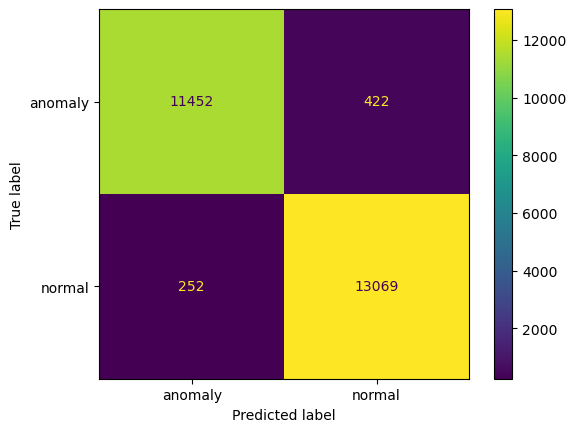

In [58]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(clf, X_val_prep, y_val, values_format="3g")

## 2.- Métricas derivadas de la matriz de confusión

In [63]:
### Precisión (Accuracy)
from sklearn.metrics import precision_score
print("Precisión:", precision_score(y_val, y_pred, pos_label= "anomaly"))

Precisión: 0.9784688995215312


### Recall 

In [66]:
from sklearn .metrics import recall_score
print("recall:", recall_score(y_val, y_pred, pos_label= 'anomaly'))

recall: 0.9644601650665319


### Curvas ROC y PR

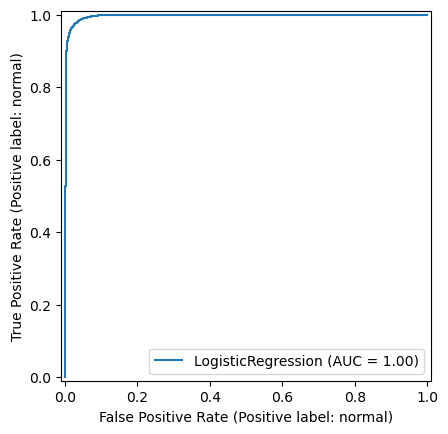

In [72]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(clf, X_val_prep, y_val)

### Curva PR 

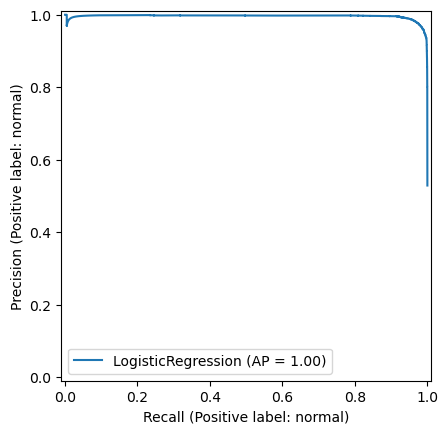

In [75]:
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_estimator(clf, X_val_prep, y_val)

## 4.- Evaluación del Modelo con el DataSet de pruebas

In [80]:
X_test_prep = data_preparer.transform(X_test)
y_pred= clf.predict(X_test_prep)

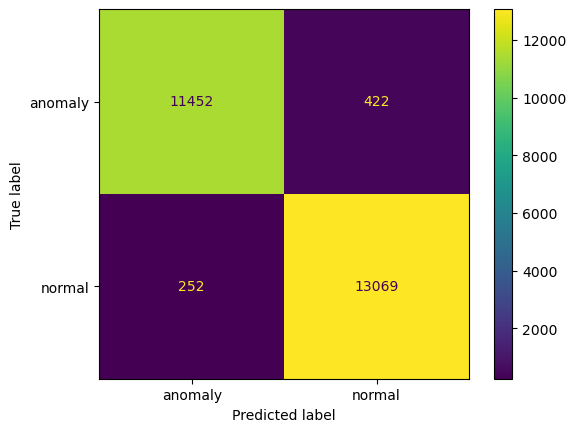

In [82]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(clf, X_val_prep, y_val, values_format="3g")

In [84]:
from sklearn.metrics import f1_score
print ("F1 score", f1_score(y_test, y_pred, pos_label= 'anomaly'))

F1 score 0.9691137935478328
